In [101]:
import pickle

# Load variables from the pickle file
with open("variables.pkl", "rb") as f:
    variables = pickle.load(f)

# Add the variables to the current notebook's namespace
globals().update(variables)

print("Variables loaded successfully.")


Variables loaded successfully.


### Table 1. Useful equations.

| Number |Equation | Description |
|:---------- |:---------- |:---------- |
1| $$SLR = \frac{Q}{A}$$                                                                                                                     | **SLR**: Surface Loading Rate<br>**Q**: inflow<br>**A**: surface area                                                                                                    |
2| $$t = \frac{Volume}{Q} = \frac{H}{SLR}$$                                                                                                   | **t**: detention time<br>**Volume**: Volume<br>**Q**: inflow<br>**H**: water depth in the tank<br>**SLR**: Surface Loading Rate                                               |
3| $$Q_{perV-notch} = \frac{8}{15} C_d \sqrt{2g} \tan{\frac{\theta}{2}} h^{\frac{5}{2}}$$                                                       | **$Q_{perV-notch}$**: flow over v-notch<br>**$C_d$**: discharge coefficient<br>**g**: acceleration due to gravity<br>**$\theta$**: angle of the v-notch<br>**h**: maximum height of water over weirs |
4| $$Q_{perV-notch} = \frac{Q}{N}$$                                                                                                           | **$Q_{perV-notch}$**: flow over v-notch<br>**Q**: inflow<br>**N**: number of v-notches                                                                                     |
5| $$v_h = \frac{Q}{WH} = \frac{L}{t}$$                                                                                                       | **$v_h$**: horizontal velocity<br>**Q**: inflow<br>**W**: tank width<br>**H**: tank depth<br>**t**: detention time<br>**L**: tank length                                    |
6| $$v_H = \sqrt{\frac{8k(s-1)gd}{f}}$$                                                                                                       | **$v_H$**: scour velocity<br>**k**: scoured material constant<br>**s**: spec. gravity of particles<br>**g**: acceleration due to gravity<br>**d**: particle diameters<br>**f**: Darcy-Weisbach friction factor |
7| $$y_c = \left[ \frac{(qL)^2}{4b^2g} \right]^{\frac{1}{3}}$$                                                                                 | **$y_c$**: critical depth<br>**q**: discharge per unit launder length<br>**L**: the length of the launder<br>**b**: the width of the launder<br>**g**: acceleration due to gravity |
8| $$H = \left( y_c^2 + \frac{2q^2x^2}{gb^2y_c} \right)^{\frac{1}{2}}$$                                                                       | **H**: total head<br>**$y_c$**: critical depth<br>**q**: discharge per unit launder length<br>**x**: distance (L/2 for a circular basin)<br>**g**: acceleration due to gravity<br>**b**: the width of the launder |
9| $$R = \frac{t}{a + bt}$$                                                                                                                   | **R**: efficiency in %<br>**t**: residence time in hours<br>**a**: parameter<br>**b**: parameter                                                                          |

---
**Standard Parameters (Table P.C.1)**

| Constituent | a      | b      |
| :---------- | :----- | :----- |
| BOD₅        | 0.018  | 0.020  |
| SS          | 0.0075 | 0.014  |

**Design Guidelines (Table P.C.2)**

| Parameter | Value | 
|-----------|-------| 
| Detention time, t <br> <div style="margin-left: 20px;"> For average dry weather flow </div> | 1.5 and 2.5 hours | 
| Surface loading rate, SLR <br><div style="margin-left: 20px;">For average dry weather flow <br> For peak flow conditions</div> | <br> 32 - 49 $m^3/m^2/day$ <br> 49 - 122 $m^3/m^2/day$ | 
| Clarifier diameter | 10 – 60 m | 
| Sidewater depth, H | 2.1 – 5 m | 
| Weir loading rate, WLR | 125 – 500 $m^3/m/day$ | 
| 90° V-notch weirs <br><div style="margin-left: 20px;"> Height safety factor <br> $C_d$ </div> | <br> 15% additional <br> 0.58 | 
| Launder depth safety factor | 50% additional depth | 

In [102]:
# Design Guidelines Checklist

import pandas as pd
import numpy as np

check_list = [
    ['Detention time, t', '1.5 - 2.5 hr', '-'],
    ['Surface Loading Rate, SLR (ADW)', '30 - 50 m³/m²/day', '-'],
    ['Surface Loading Rate, SLR (PHR)', '60 - 120 m³/m²/day', '-'],
    ['Clarifier Diameter', '3 - 60 m', '-'],
    ['Sidewater depth, H', '3.0 - 5.0 m', '-'],
    ['Weir Loading Rate, WLR', '125 - 500 m³/m/day', '-']
]

headers = ["Parameter", "Typical Value", "Notes"]

# Create a DataFrame with data checklist
df = pd.DataFrame(check_list, columns=headers)
# During the design process the items contained whithin the DataFrame will be marked as "OK"


'''Functions'''

# Weir length for circular clarifiers (Lw)
def weir_length_circtank(n_side, tank_diameter, dist_cent_edge):
    """
    Calculates the weir length for circular clarifiers.

    Args:
        n_side (int): Number of sides of the launder (1 or 2).
        tank_diameter (float): Diameter of the circular tank in meters.
        dist_cent_edge (float): Distance from edge of clarifier to centerline of launder (m)

    Returns:
        float: The weir length in meters, or None if n_side is invalid.
    """
    if not isinstance(tank_diameter, (int, float)) or not isinstance(dist_cent_edge, (int, float)) or not isinstance(n_side, (int, float)):
        print("Error: All arguments must be a number.")
        return None
    
    if n_side == 1:
        launder_length = np.pi * tank_diameter  # Launder Length "m"
        weir_length = launder_length     # Weir Length "m"
        return weir_length
    
    elif n_side == 2:
        '''
        while True:
            dist_str = input("Distance from edge of clarifier to centerline of launder (m): ")
            # User must provide the centerline distance from edge
            try:
                dist_launder_centerline_edge = float(dist_str)
                break  # Exit the loop if input is valid
            except ValueError:
                print("Invalid input. Please enter a valid number for the distance.")
        '''
        launder_length = np.pi * (tank_diameter - 2 * dist_cent_edge)  # Launder Length "m"
        weir_length = n_side * launder_length     # Weir Length "m"
        return weir_length
    else:
        print("The sides of the launder must be defined as 1 or 2")
        return None

# Maximum water height over the weirs (bottom of the notch) (h).
def max_height_water_weirs (Q_notch, Cd, gravity, theta):
    """
    Calculates the maximum water height over the weirs.

    Args:
        Q_notch (float): Flow rate per V-notch.
        Cd (float): Discharge coefficient depending on the weir geometry and flow conditions, typically 0.58.
        Gravity (float): Gravity acceleration = 9.81 m/s², usually.
        theta (float): Angle of the V-notch in degrees.

    Returns:
        h (float): Head of water above the bottom of the notch in meters, or None if any argument is invalid.
    """
    # Convert theta degrees to radians
    theta_rad = np.deg2rad(theta)
    h = (Q_notch/(8/15 * Cd * np.sqrt( 2 * gravity ) * np.tan(theta_rad/2) ) )**(2/5)
    return h

# Critical water height at launder discharge point (Yc)
def critical_Yc (q_WLR, launder_length, launder_width, gravitiy):
    """
    Calculates the maximum water height over the weirs.

    Args:
        q_WLR (float): Discharge per unit launder length (m³/m/s).
        launder_legnth (float): Length of the launder, for circular tanks x = launder_length/2 (m).
        launder_width (float): Width of the launder (m).
        Gravity (float): Gravity acceleration = 9.81 m/s², usually.

    Returns:
        Yc (float): Critical water height at launder discharge point in meters, or None if any argument is invalid.
    """
    if not isinstance(q_WLR, (int, float)) or not isinstance(launder_length, (int, float)) or not isinstance(launder_width, (int, float)) or not isinstance(gravitiy, (int, float)):
        print("Error: the input arguments must be a number.")
        return None

    # Determine the critical water height (Yc) at discharge point.
    Yc = (((q_WLR * launder_length/2)**2) / (4 * (launder_width**2) * gravitiy))**(1/3)
    return Yc

# Maximum depth of water into the launder (H)
def max_water_launder_H (q_WLR, x_water, launder_width, gravitiy, crit_Yc):
    """
    Calculates the maximum water height over the weirs.

    Args:
        q_WLR (float): Discharge per unit launder length (m³/m/s).
        x_water (float): farthest distance water travels (m).
        launder_width (float): Width of the launder (m).
        Gravity (float): Gravity acceleration = 9.81 m/s², usually.
        Yc (float): Critical water height at launder discharge point (m).
    Returns:
        H (float): Maximum depth of water into the launder in meters, or None if any argument is invalid.
    """
    if not isinstance(q_WLR, (int, float)) or not isinstance(x_water, (int, float)) or not isinstance(launder_width, (int, float)) or not isinstance(gravitiy, (int, float)) or not isinstance(crit_Yc, (int, float)):
        print("Error: the input arguments must be a number.")
        return None

    # Determine the maximum depth of water into the launder.
    H = (crit_Yc**2 + ((2* (q_WLR**2) * (x_water)**2) / (gravitiy * (launder_width**2) * crit_Yc)))**(1/2)
    return H

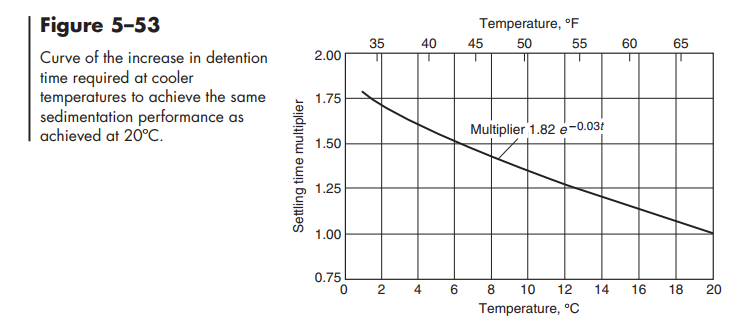

In [ ]:
'''First Trial'''

# 0. Primary information:

Q_ADW = Q_total_projected_average/24    # Projected Average Dry Weather flow rate (m³/hr)
Q_PHR = Q_total_projected_maximum/24    # (Peak) Maximum hourly flow rate (m³/hr)

print(f"Projected Average Dry Weather flow rate (Q_ADW): {Q_ADW:.2f} m³/hr")
print(f"(Peak) Maximum hourly flow rate (Q_PHR): {Q_PHR:.2f} m³/hr\n")

# BOD5 concentration in the influent (mg/L)
BOD5_influent = 370  # BOD5 concentration in the influent (mg/L)

# BOD5 concentration in the effluent (mg/L)
BOD5_effluent = 259  # BOD5 concentration in the effluent (mg/L)

# BOD5 removal efficiency
R_BOD = (BOD5_influent - BOD5_effluent) / BOD5_influent *100  # BOD5 removal efficiency (%)
print(f"BOD5 removal efficiency: {R_BOD:.2f}%")

# 1. Determine the time of residence (t) according to the efficiency of BOD removal and determine 
# the efficiency of the the suspended solids (SS) removal from detention time (t).

'''From Table P.C.1 "Standard parameter" the time of residence for the SS removal and BOD removal is as follows:'''

a_BOD = 0.018
b_BOD = 0.020

t = R_BOD*a_BOD/(1-R_BOD*b_BOD)  # Time of residence (hours)
print(f"Time of residence (t): {t:.2f} hours")

# To achieve the same sedimentation performance as achieved at 20ºC is necessary to increase the time of residence (t) by a multiplier factor,
# which is a function of the temperature of the water. The multiplier factor is given by the following equation:
temperature = 10  # Temperature in degrees Celsius
multiplier_factor = 1.82 * np.exp(-0.03 * temperature)  # Multiplier factor
print(f"Multiplier factor for temperature {temperature:.0f}°C: {multiplier_factor:.2f}")

# Calculate the adjusted time of residence (t) using the multiplier factor
t_adjusted = t * multiplier_factor  # Adjusted time of residence (hours)
#print(f"Adjusted time of residence (t) at {t_adjusted:.0f}°C of water temperature: {t_adjusted:.2f} hours")

# Determine the suspended solids (SS) removal efficiency from the detention time (t)
# Given paramaters for SS removal efficiency.
a_SS = 0.0075 
b_SS = 0.014

# Calculate the suspended solids (SS) removal efficiency using the detention time (t)
R_SS = t/(a_SS + b_SS*t) # SS removal efficiency (%)
print(f"Suspended solids (SS) removal efficiency: {R_SS:.2f}%")


print(f"Adjusted time of residence (t) at {temperature:.0f}°C of water temperature: {t_adjusted:.2f} hours")

Projected Average Dry Weather flow rate (Q_ADW): 4205.45 m³/hr
(Peak) Maximum hourly flow rate (Q_PHR): 7465.79 m³/hr

BOD5 removal efficiency: 30.00%
Time of residence (t): 1.35 hours
Multiplier factor for temperature 10°C: 1.35
Suspended solids (SS) removal efficiency: 51.14%
Adjusted time of residence (t) at 10°C of water temperature: 1.82 hours


In [104]:
# The time of residence is equal to 1.86 hours.

# 2. The total volume of the clarifier tanks is determined by the detention time (t) and the peak hourly 
# flow rate (Q_PHR) using the following equation (Equation 1 from Table P.C.2):

V_total = Q_PHR * t_adjusted # Total volume given by the time of residence (t "h") over the peak flow conditions (Q_PHR "m³/hr")
print(f"Total volume of clarifier tanks is: {V_total:.2f} m³")

# 3. It's checked that the detention time is not less than 1.5 hours or greater than 2.5 hours (see guidelines Table P.C.2) for average dry flow rate condition.

# It's obvious that the detention time to be determined is not less than 1.5 hours due to the fact that the volume of the clarifier tanks is calculated using the peak hourly flow rate (Q_PHR),
# with t = 1.86 hours and knowing that the average dry flow rate (Q_ADW) is lower than (Q_PHR). Hence, the detention time by average dry weather flow rate is determined as follows:

t_ADW = V_total / Q_ADW  # Detention time for average dry weather flow rate (hours)
print(f"Detention time for average dry weather flow rate: {t_ADW:.2f} hours")

Total volume of clarifier tanks is: 13589.15 m³
Detention time for average dry weather flow rate: 3.23 hours


In [105]:
# The detention time for average dry weather flow rate is equal to 3.98 hours, which is greater than 2.5 hours. 
# Thus, using the maximum detention time for Q_ADW allowed by the guidelines, the volume of the clarifier
# tanks is recalculated using the maximum detention time of 2.5 hours:

t_ADW_max = 2.5  # Maximum detention time for average dry weather flow rate (hours)
V_ADW_max = Q_ADW * t_ADW_max  # Volume of clarifier tanks using maximum detention time (h) for Q_ADW (m³/h) condtions (m³).
print(f"Volume of clarifier tanks (using maximum detention time for ADW): {V_ADW_max:.2f} m³")

# 4. The excess volume of the clarifier tanks is calculated as follows:

V_excess = V_total - V_ADW_max  # Excess volume of clarifier tanks (m³)
# This volume will be determined as the volume for the equalization tank, which is used to balance the flow rate and the volume of the clarifier tanks.
print(f"Excess volume of clarifier tanks (equalization tank volume): {V_excess:.2f} m³\n")

Volume of clarifier tanks (using maximum detention time for ADW): 10513.62 m³
Excess volume of clarifier tanks (equalization tank volume): 3075.53 m³



In [106]:
'''In this point just the time of residence or detention time (t) meets the design guidelines (Table. P.C.2)'''

# Let's change the status in the last column of the check list regarding "detention time"
df.iloc[0, 2] = 'OK'
print(df)
print('\n')

# 5. Having the new volume of the clarifier tanks, a new peak hourly flow rate is calculated using the new volume of 
# the clarifier tanks and the maximum detention time for peak hourly flow condition, meeting the minimum
# removal efficiency for SS and BOD removal requirements.

# The new peak hourly flow rate is calculated as follows:
# Q_PHR_new = V_ADW_max / (t * conv_h_to_s)  # New peak hourly flow rate (m³/hr)
# print(f"New peak hourly flow rate: {Q_PHR_new:.2f} m³/s")

Q_PHR_new = V_ADW_max / t_adjusted  # New peak hourly flow rate (m³/hr)
print(f"New peak hourly flow rate (Q_PHR*): {Q_PHR_new:.2f} m³/hr")

print(f"Average dry weather flow rate (Q_ADW): {Q_ADW:.2f} m³/hr")

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr    OK
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day     -
2  Surface Loading Rate, SLR (PHR)  60 - 120 m³/m²/day     -
3               Clarifier Diameter            3 - 60 m     -
4               Sidewater depth, H         3.0 - 5.0 m     -
5           Weir Loading Rate, WLR  125 - 500 m³/m/day     -


New peak hourly flow rate (Q_PHR*): 5776.11 m³/hr
Average dry weather flow rate (Q_ADW): 4205.45 m³/hr


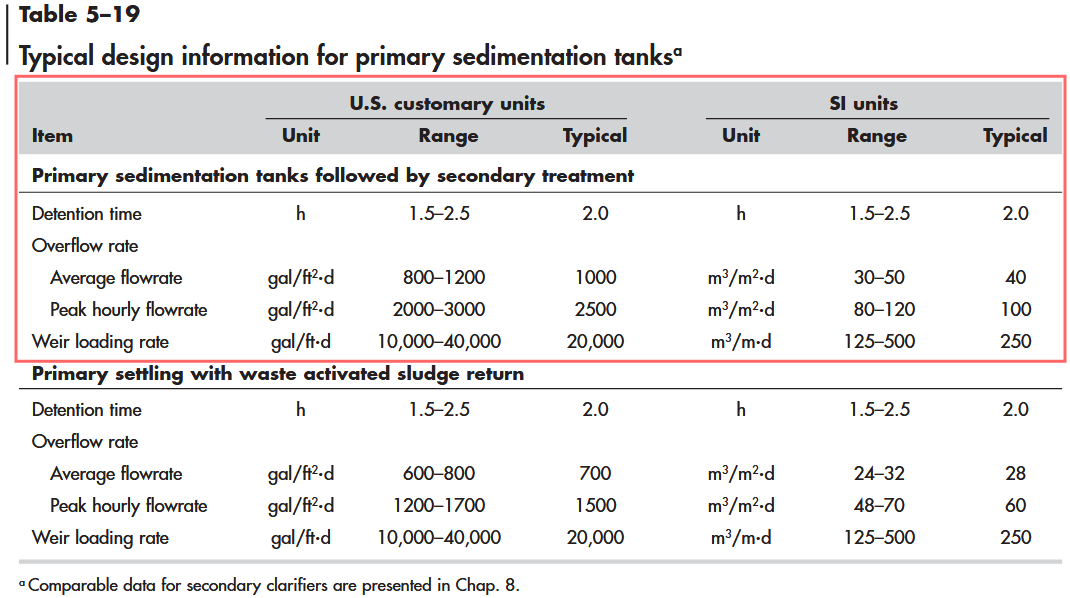

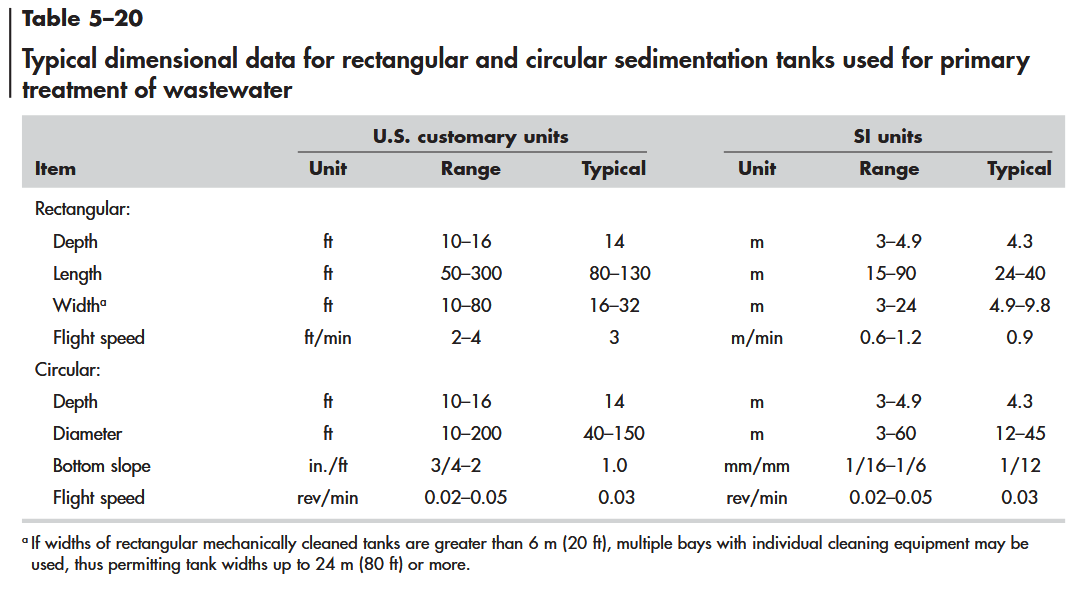

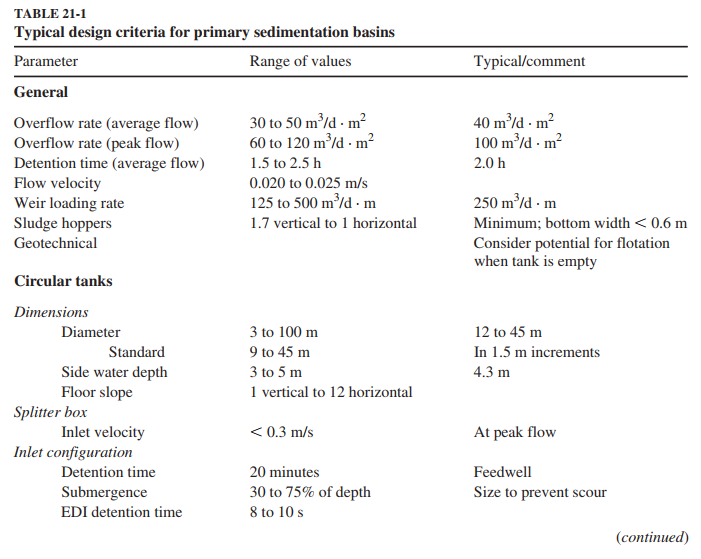
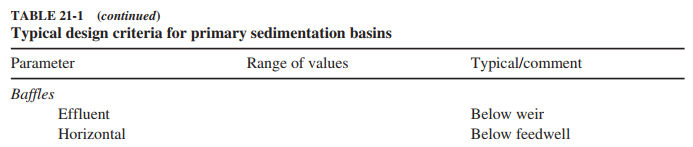

In [107]:
# 6. The Surface Loading Rate (SLR) is calculated for both cases, average dry flow (ADW) and peak flow conditions (PHR)

# It's determined the surface area from the volume of the clarifier tank

# In this scenario, it is assumed to work with one clarifier tank:

# Sidewater depth (m) (Table 21-1), it will have a freeboard of 0.5m.
H_clarifier = 5  # Total tank depth = 5.0 + 0.5 = 5.5m
print(f"Sidewater depth: {H_clarifier:.2f} m")

V_tanks = V_ADW_max  # Volume of the clarifier tank (m³)
print(f"Volume of clarifier tank: {V_tanks:.2f} m³")

# The area of the clarifier tank is calculated as follows:
A_clarifiers = V_tanks / H_clarifier
print(f'Area of clarifier tank: {A_clarifiers:.1f} m²')

# The diameter of the clarifier tank is calculated as follows:
D_clarifiers = np.sqrt(4 * A_clarifiers / np.pi)  # Diameter of the clarifier tanks (m)
print(f'Diameter of clarifier tank: {D_clarifiers:.1f} m\n')

'''The diameter of the clarifier tanks is equal to 51.7 m (below of Dmax = 60m), which is within the design requirements (Table 5-20)'''
'''It means that for this trial only will be needed one clarifier tank'''

# From Equation 1 in Table P.C.2

# The SLR for PHR is:
SLR_PHR = (Q_PHR_new / A_clarifiers) * 24  # SLR for PHR (m³/m²/day)
print(f'The Surface Loading Rate of the clarifier tank for peak flow conditions is: {SLR_PHR:.1f} m³/m²/day')
# The SLR for ADW is:
SLR_ADW = (Q_ADW / A_clarifiers) * 24  # SLR for ADW (m³/m²/day)
print(f'The Surface Loading Rate of the clarifier tank for average dry flow is: {SLR_ADW:.1f} m³/m²/day\n')

# Let's change the status in the last column of the checklist.
df.iloc[1, 2] = 'OK'
df.iloc[2, 2] = 'OK'
df.iloc[3, 2] = 'OK'
df.iloc[4, 2] = 'OK'
print(df)
print('\n')

"""One clarifier tank is used for the design, both SLR for AWD and PHR meet the design requirements (Table 21-1)"""

"""To check the weir loading rate (WLR) for the clarifier tank, it is necessary assume the critical condition
for the operation of the clarifier tanks. To analyze the critical condition, it is necessary to design the primary
treatment system composed by minimum two clarifier tanks. The critical condition occurs when at leas one clarifier
tank is out of service. (reliability, redundancy, maintenance needs)"""


Sidewater depth: 5.00 m
Volume of clarifier tank: 10513.62 m³
Area of clarifier tank: 2102.7 m²
Diameter of clarifier tank: 51.7 m

The Surface Loading Rate of the clarifier tank for peak flow conditions is: 65.9 m³/m²/day
The Surface Loading Rate of the clarifier tank for average dry flow is: 48.0 m³/m²/day

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr    OK
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day    OK
2  Surface Loading Rate, SLR (PHR)  60 - 120 m³/m²/day    OK
3               Clarifier Diameter            3 - 60 m    OK
4               Sidewater depth, H         3.0 - 5.0 m    OK
5           Weir Loading Rate, WLR  125 - 500 m³/m/day     -




'To check the weir loading rate (WLR) for the clarifier tank, it is necessary assume the critical condition\nfor the operation of the clarifier tanks. To analyze the critical condition, it is necessary to design the primary\ntreatment system composed by minimum two clarifier tanks. The critical condition occurs when at leas one clarifier\ntank is out of service. (reliability, redundancy, maintenance needs)'

In [108]:
"""Second Trial"""

print("Second Trial: Adding another clarifier tank\n")

# The design guidelines checklist is re-reseted:

df.iloc[0, 2] = '-'
df.iloc[1, 2] = '-'
df.iloc[2, 2] = '-'
df.iloc[3, 2] = '-'
df.iloc[4, 2] = '-'
print(df)
print('\n')

# 8. The number of clarifier tanks is determined:
n_clarifiers = 2  # Number of clarifier tanks

# The volume of the clarifier tank is calculated as follows:
V_per_clarifier = V_tanks / n_clarifiers  # Volume of the clarifier tank (m³)
print(f'Volume of clarifier tank: {V_per_clarifier:.1f} m³')

# The area of the clarifier tank is calculated as follows:
A_per_clarifier = V_per_clarifier / H_clarifier  # Area of the clarifier tank (m²)
print(f'Area of clarifier tank: {A_per_clarifier:.1f} m²')

# The diameter of the clarifier tank is calculated as follows:
D_per_clarifier = np.sqrt(4 * A_per_clarifier / np.pi)  # Diameter of the clarifier tanks (m)
print(f'Diameter of clarifier tank: {D_per_clarifier:.1f} m\n')

'''The diameter of the clarifier tanks is equal to 36.6 m (below of Dmax = 60m or 45m), which is within the design requirements (Table 5-20 and Table 21-1)'''
'''It means that the dimensions of the clarifier tanks are OK for the design.'''

"""The SLR condition is checked, but it's obvuous that SLR meets the design requirements (Table 21-1) for both cases,"""
# 9. The SLR for PHR is:
SLR_PHR = (Q_PHR_new / (A_per_clarifier * n_clarifiers)) * 24  # SLR for PHR (m³/m²/day)
print(f'The Surface Loading Rate of the clarifier tank for peak flow conditions is: {SLR_PHR:.1f} m³/m²/day')
# The SLR for ADW is:
SLR_ADW = (Q_ADW / (A_per_clarifier * n_clarifiers)) * 24  # SLR for ADW (m³/m²/day)
print(f'The Surface Loading Rate of the clarifier tank for average dry flow is: {SLR_ADW:.1f} m³/m²/day\n')

# Let's change the status in the last column of the checklist.
df.iloc[0, 2] = 'OK'
df.iloc[1, 2] = 'OK'
df.iloc[2, 2] = 'OK'
df.iloc[3, 2] = 'OK'
df.iloc[4, 2] = 'OK'
print(df)
print('\n')

Second Trial: Adding another clarifier tank

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr     -
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day     -
2  Surface Loading Rate, SLR (PHR)  60 - 120 m³/m²/day     -
3               Clarifier Diameter            3 - 60 m     -
4               Sidewater depth, H         3.0 - 5.0 m     -
5           Weir Loading Rate, WLR  125 - 500 m³/m/day     -


Volume of clarifier tank: 5256.8 m³
Area of clarifier tank: 1051.4 m²
Diameter of clarifier tank: 36.6 m

The Surface Loading Rate of the clarifier tank for peak flow conditions is: 65.9 m³/m²/day
The Surface Loading Rate of the clarifier tank for average dry flow is: 48.0 m³/m²/day

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr    OK
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day    OK
2  Surface Loading Rate, SLR (PHR)  60 - 120 m³/m²/day    

In [109]:

# 10. Weir Loading Rate (WLR) of the clarifier tanks

# It's defined the number of clarifier tanks at critical condition as follows:

n_clarifiers_critical = n_clarifiers - 1   # Critical condition
print(f'Number of clarifier tanks at critical condition: {n_clarifiers_critical}\n')

# First, the weir length (Lw) for circular tanks is determined using the funtion described at beginning of this notebook:

'''It's assumed that the clarifier tank launder is 2-sided and it has a distance from its centerline to
the edge of the clarifier tank equal to 1.0m.'''
# This dimension assumed will be used to calculate the weir length (Lw) for circular tanks.

sides_launder = 2   # 2-sided launder
dist_cent_edgetank = 1  # Distance from clarifier edge to centerline of the launder

# Applying the function defined at the beginning of this notebook to determine the weir length
weir_length = weir_length_circtank(sides_launder, D_per_clarifier, dist_cent_edgetank)  # 2-sided clarifier, tank_diameter = D_clarifier, centerline 1m from edge

# Then, the WLR is calculated from the next equation:
WLR = (Q_PHR_new * 24) / weir_length

# In the critical condition, WLR is determined as follows:
WLR_crit = WLR / n_clarifiers_critical  # Weir Loading Rate (m³/m²/day)
print(f'The Weir Loading Rate of the clarifier tank is: {WLR_crit:.1f} m³/m/day\n')

"""The WLR calculted (637.9) m³/m/day) exceed the upper limit defined by the design requirements (500 m³/m²/day) (Table 21-1)"""

Number of clarifier tanks at critical condition: 1

The Weir Loading Rate of the clarifier tank is: 637.9 m³/m/day



'The WLR calculted (637.9) m³/m/day) exceed the upper limit defined by the design requirements (500 m³/m²/day) (Table 21-1)'

In [110]:
'''Third Trial'''

print("Third Trial: Adding another clarifier tank to reduce WLR\n")

# The design guidelines checklist is re-reseted:

df.iloc[0, 2] = '-'
df.iloc[1, 2] = '-'
df.iloc[2, 2] = '-'
df.iloc[3, 2] = '-'
df.iloc[4, 2] = '-'
print(df)
print('\n')


# 11. Thus, another tank must be added to decrease the WLR for whole system

n_clarifiers = n_clarifiers + 1  # Number of clarifier tanks
print(f"Number of the clarifiers in this trial: {n_clarifiers:.0f} \n")

# The volume of the clarifier tank is calculated as follows:
V_per_clarifier = V_tanks / n_clarifiers  # Volume of the clarifier tank (m³)
print(f'Volume of clarifier tank: {V_per_clarifier:.1f} m³')

# The area of the clarifier tank is calculated as follows:
A_per_clarifier = V_per_clarifier / H_clarifier  # Area of the clarifier tank (m²)
print(f'Area of clarifier tank: {A_per_clarifier:.1f} m²')

# The diameter of the clarifier tank is calculated as follows:
D_per_clarifier = np.sqrt(4 * A_per_clarifier / np.pi)  # Diameter of the clarifier tanks (m)
print(f'Diameter of clarifier tank: {D_per_clarifier:.1f} m\n')

'''The diameter of the clarifier tanks is equal to 36.6 m (below of Dmax = 60m or 45m), which is within the design requirements (Table 5-20 and Table 21-1)'''
'''It means that the dimensions of the clarifier tanks are OK for the design.'''

"""The SLR condition is checked, but it's obvuous that SLR meets the design requirements (Table 21-1) for both cases,"""
# 12. The SLR for PHR is:
SLR_PHR = (Q_PHR_new / (A_per_clarifier * n_clarifiers)) * 24  # SLR for PHR (m³/m²/day)
print(f'The Surface Loading Rate of the clarifier tank for peak flow conditions is: {SLR_PHR:.1f} m³/m²/day')
# The SLR for ADW is:
SLR_ADW = (Q_ADW / (A_per_clarifier * n_clarifiers)) * 24  # SLR for ADW (m³/m²/day)
print(f'The Surface Loading Rate of the clarifier tank for average dry flow is: {SLR_ADW:.1f} m³/m²/day\n')

# Let's change the status in the last column of the checklist.
df.iloc[0, 2] = 'OK'
df.iloc[1, 2] = 'OK'
df.iloc[2, 2] = 'OK'
df.iloc[3, 2] = 'OK'
df.iloc[4, 2] = 'OK'
print(df)
print('\n')

Third Trial: Adding another clarifier tank to reduce WLR

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr     -
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day     -
2  Surface Loading Rate, SLR (PHR)  60 - 120 m³/m²/day     -
3               Clarifier Diameter            3 - 60 m     -
4               Sidewater depth, H         3.0 - 5.0 m     -
5           Weir Loading Rate, WLR  125 - 500 m³/m/day     -


Number of the clarifiers in this trial: 3 

Volume of clarifier tank: 3504.5 m³
Area of clarifier tank: 700.9 m²
Diameter of clarifier tank: 29.9 m

The Surface Loading Rate of the clarifier tank for peak flow conditions is: 65.9 m³/m²/day
The Surface Loading Rate of the clarifier tank for average dry flow is: 48.0 m³/m²/day

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr    OK
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day    OK
2 

In [111]:
# 13. Weir Loading Rate (WLR) of the clarifier tanks (for 3 clarifier tanks)

# Again, it is defined the number of clarifier tanks at critical condition as follows:

n_clarifiers_critical = n_clarifiers - 1   # Critical condition
print(f'Number of clarifier tanks at critical condition: {n_clarifiers_critical}\n')

# First, the weir length (Lw) for circular tanks is determined using the funtion described at beginning of this notebook:

'''It's assumed that the clarifier tank launder is 2-sided and it has a distance from its centerline to
the edge of the clarifier tank equal to 1.0m.'''
# This dimension assumed will be used to calculate the weir length (Lw) for circular tanks.

sides_launder = 2   # 2-sided launder
dist_cent_edgetank = 1  # Distance from clarifier edge to centerline of the launder

# Applying the function defined at the beginning of this notebook to determine the weir length
weir_length = weir_length_circtank(sides_launder, D_per_clarifier, dist_cent_edgetank)  # 2-sided clarifier, tank_diameter = D_clarifier, centerline 1m from edge

# Then, the WLR is calculated from the next equation:
WLR = (Q_PHR_new * 24) / weir_length

# In the critical condition, WLR is determined as follows:
WLR_crit = WLR / n_clarifiers_critical  # Weir Loading Rate (m³/m²/day)
print(f'The Weir Loading Rate of the clarifier tank is: {WLR_crit:.1f} m³/m/day\n')

"""The WLR calculted (387.6 m³/m/day) does not exceed the upper limit defined by the design requirements (500 m³/m²/day) (Table 21-1)"""
'''The design guidelines checklist is updated'''

df.iloc[5, 2] = 'OK'
print(df)
print('\n')

"""All the design requirements are met for the clarifier tanks, and the design is OK."""

Number of clarifier tanks at critical condition: 2

The Weir Loading Rate of the clarifier tank is: 395.8 m³/m/day

                         Parameter       Typical Value Notes
0                Detention time, t        1.5 - 2.5 hr    OK
1  Surface Loading Rate, SLR (ADW)   30 - 50 m³/m²/day    OK
2  Surface Loading Rate, SLR (PHR)  60 - 120 m³/m²/day    OK
3               Clarifier Diameter            3 - 60 m    OK
4               Sidewater depth, H         3.0 - 5.0 m    OK
5           Weir Loading Rate, WLR  125 - 500 m³/m/day    OK




'All the design requirements are met for the clarifier tanks, and the design is OK.'

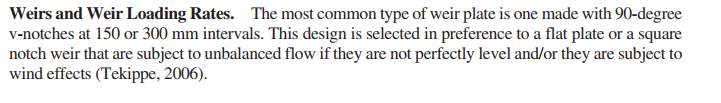
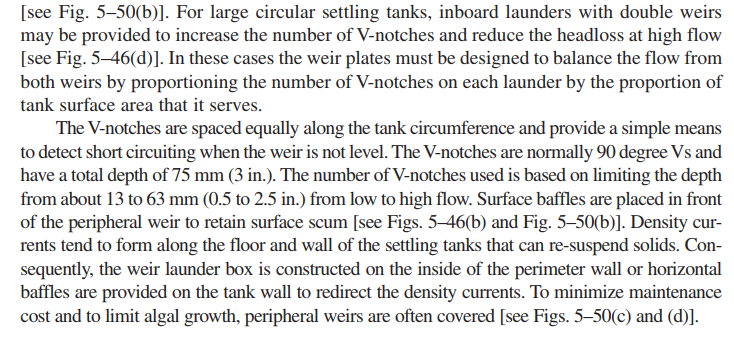

In [112]:
'''Design of V-Notches'''

print("Design of V-Notches\n")

# The design of the V-Notches is based on the following assumptions:

# 1. The number of V-Notches is determined based on centre-centre spacing between them

# Then, is assumed that the centre to centre spacing is 300mm.
S_v_notch = 0.3  # Centre to centre spacing between V-Notches (m)

# The number of V-Notches is calculated as follows:
N_notches = np.ceil(weir_length / S_v_notch)
print(f'The number of V-Notches per clarifier is: {N_notches:.0f}\n')

# 2. Calculation of the flow rate per V-Notch

# It's defined the total amount of V-Notches for all clarifiers as follows:
N_total_notches = N_notches * n_clarifiers # Clarifier tanks 3
print(f'The total number of V-Notches for all clarifiers is: {N_total_notches:.0f} \n')

# The flow per notch is determined based on the following equation (Equation 4 from Table P.C.2):
# It's based on Q_PHR_new, which is the new peak hourly flow rate (Q_PHR*) calculated previously.
Q_Vnotch = (Q_PHR_new / 3600) / N_total_notches
print(f'The flow per each V-Notch is: {Q_Vnotch:.6f} m³/s\n')

# 4. The maximum height of water over weirs (h) is determined based on Equation 3, solve for "h":

Cd = 0.58   # Predetermined
theta_V = 90  # V-notch angle
g = 9.81    # gravity acceleration (m/s²)

h_max_height_water_over_weirs = max_height_water_weirs(Q_Vnotch, Cd, g, theta_V)
print(f'The maximum height of water over weirs is: {h_max_height_water_over_weirs:.3f} m')
print(f'The maximum height of water over weirs is: {(1000*h_max_height_water_over_weirs):.0f} mm\n')

"""The height of water over the weirs is between 13mm and 63mm, which is within the design requirements by Metcalf & Eddy"""

# 5. The water depth is determined based on the safety factor (15%).

SF_water_notch = 0.15
y = (1 + SF_water_notch) * h_max_height_water_over_weirs  # Water depth over weirs (m)

print(f'The water depth over weirs (safety factor) is: {y:.3f} m')
print(f'The water depth over weirs (safety factor) is: {(1000*y):.0f} mm\n')


# 6. The width of the V-notch at the top is two times the water depth (y)

width_notch = 2 * y  # Width of the V-notch at the top (m)
print(f'The width of the V-notch at the top is: {width_notch:.3f} m')
print(f'The width of the V-notch at the top is: {(1000*width_notch):.0f} mm\n')



Design of V-Notches

The number of V-Notches per clarifier is: 584

The total number of V-Notches for all clarifiers is: 1752 

The flow per each V-Notch is: 0.000916 m³/s

The maximum height of water over weirs is: 0.054 m
The maximum height of water over weirs is: 54 mm

The water depth over weirs (safety factor) is: 0.062 m
The water depth over weirs (safety factor) is: 62 mm

The width of the V-notch at the top is: 0.124 m
The width of the V-notch at the top is: 124 mm



In [113]:
# 7. The discharge per unit length of launder is determined as follows:

q_wlr = WLR_crit / 86400 * sides_launder   # It's defined by the 2-sided launder (fed from both sides)
print(f'The discharge (q) per unit length of the launder is: {q_wlr:.4f} m³/m/s\n')

# 8. The critical height of water at launder discharge point (Yc) is determined based on the Equation 5 from Table P.C.2
# The clarifiers only have one discharge point.
n_disch_points = 1

# The perimeter of the clarifier is calculated:
# The perimiteter of the 2-sided launder clarifier tank is equal to the weir length (Lw) divided by sides_launder.
perimeter_clarifier = weir_length / sides_launder  # Perimeter of the clarifier (m)
print(f'The perimeter of the clarifier is: {perimeter_clarifier:.1f} m')

# The farthest distance that water travels into the launder is calculated as follows:
x = perimeter_clarifier / (n_disch_points * 2)
print(f'The farthest distance that water travels into the launder is: {x:.2f} m\n')

# Width of the launder, previously defined as 0.5m.
width_launder = 0.5     # Width of the launder (m)

# To determine the Yc for 2-sided launder circular clarifiers is used the next function based on Equation 6.
Yc = critical_Yc(q_wlr, weir_length, width_launder, 9.81)
print(f'The critical height of water at launder discharge point (Yc) is: {Yc:.2f} m\n')

# 9. The maximum depth of water in the launder (H_water_launder) is calculated by the function defined at the beginning of this notebook.
# The maximum depth of water in the launder is determined based on the Equation 8 from Table P.C.2
"""Here is applied the x value (farthest distance)"""
H_water_launder = max_water_launder_H(q_wlr, x, width_launder, 9.81, Yc)
print(f'The maximum depth of water into the launder (H) is: {H_water_launder:.2f} m\n')


# 10. Multiplying H_water_launder by the depth safety factor (50%), defined at the beginning of this notebook, the depth of water in the launder is determined.
SF_H_depth = 0.5
H_water_launder_f = (1 + SF_H_depth) * H_water_launder
print(f'The depth of water into the launder applying the safety factor, is: {H_water_launder_f:.2f} m\n')

The discharge (q) per unit length of the launder is: 0.0092 m³/m/s

The perimeter of the clarifier is: 87.6 m
The farthest distance that water travels into the launder is: 43.78 m

The critical height of water at launder discharge point (Yc) is: 0.40 m

The maximum depth of water into the launder (H) is: 0.70 m

The depth of water into the launder applying the safety factor, is: 1.05 m

